In [14]:


# this is a credit-card fraud detection dataset. The target variable is Class, where:

# Class = 0 → Normal transaction
# Class = 1 → Fraudulent transaction
# V1–V28 → PCA-transformed transaction features
# Amount → Transaction amount
# Time → Transaction time

In [15]:
import pandas as pd
import numpy as np

In [16]:
df = pd.read_csv('../Dataset/creditcard.csv')

In [17]:
df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [18]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [20]:
# Check duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())


# Check class distribution
print("\nClass Distribution:")
print(df['Class'].value_counts())





Number of Duplicate Rows: 1081

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [21]:
# 1. Missing values:
# If the output shows 0 for every column, there are no missing values.
#
# 2. Duplicates:
# df.duplicated().sum() tells you how many duplicate transactions are present.
#
# 3. Class distribution:
# You will typically find that:
#
# Class = 0 → very large number of legitimate transactions
# Class = 1 → very small number of fraudulent transactions

In [22]:
# Check class distribution in percentage
print("\nClass Distribution (%):")
print(df['Class'].value_counts(normalize=True) * 100)


Class Distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


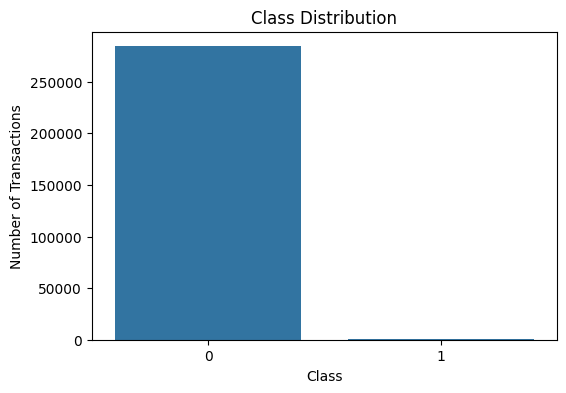

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='Class', data=df)

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

In [24]:
#EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nClass Distribution:")
print(df['Class'].value_counts())

print("\nClass Distribution Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Dataset Shape: (284807, 31)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20

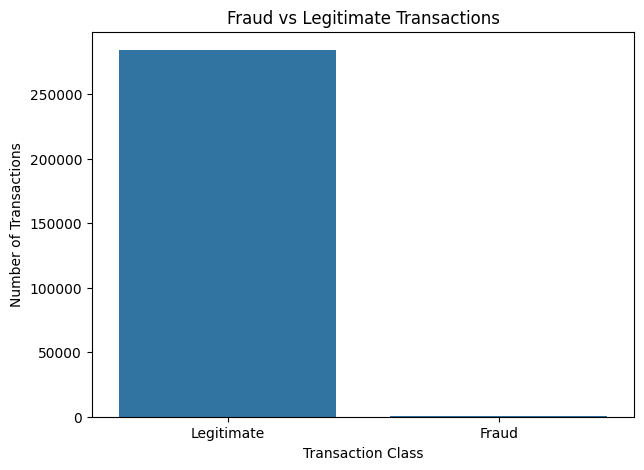

In [25]:
plt.figure(figsize=(7,5))

sns.countplot(x='Class', data=df)

plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler

# Select Amount column
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])

# Check the result
print(df[['Amount']].head())

     Amount
0  0.244964
1 -0.342475
2  1.160686
3  0.140534
4 -0.073403


In [27]:
# Features
X = df.drop('Class', axis=1)

# Target
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [29]:
#scaling

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

# Scale Amount
scaler = StandardScaler()

X_train[['Amount']] = scaler.fit_transform(X_train[['Amount']])
X_test[['Amount']] = scaler.transform(X_test[['Amount']])

print(X_train.head())

            Time        V1        V2        V3        V4        V5        V6  \
265518  161919.0  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
180305  124477.0  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
42664    41191.0 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
198723  132624.0  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
82325    59359.0 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   

              V7        V8        V9  ...       V20       V21       V22  \
265518 -1.479661  1.139880  1.406819  ... -0.134435  0.076197  0.297537   
180305 -0.002192  0.674782  0.045826  ... -0.227279  0.038628  0.228197   
42664  -2.212603 -5.037523  0.000772  ...  1.280856 -2.798352  0.109526   
198723 -1.427984  0.010010 -1.118447  ... -0.490642 -0.139670  0.077013   
82325   0.504347 -0.113817 -0.044782  ... -0.275297 -0.243245 -0.173298   

             V23       V24       V25       V26       V27       V28  

In [ ]:
#Handle class imbalance using class weights and/or SMOTE

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("CLASS WEIGHT RESULTS")

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
#How to interpret
##Metric	Meaning
#Precision	Of transactions predicted as fraud, how many were actually fraud?
#Recall	Of all actual fraud transactions, how many did the model detect?
#F1 Score	Balance between Precision and Recall
#ROC-AUC	Overall ability of the model to distinguish fraud from legitimate transactions

#For fraud detection, Recall is particularly important because missing an actual fraudulent transaction can be costly. However, you also want good Precision so that legitimate customers aren't incorrectly flagged as fraud

In [32]:
#Why use class_weight='balanced'?

#It automatically gives more importance to the minority class (Fraud) and less importance to the majority class (Legitimate).

In [33]:
!pip install imbalanced-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
#smote

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample( X_train, y_train)


In [35]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_smote, y_train_smote)

y_pred1 = model.predict(X_test)
y_prob1 = model.predict_proba(X_test)[:, 1]

C:\Users\bhave\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.91      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962



In [38]:
results = pd.DataFrame({
    'Method': ['Class Weight', 'SMOTE'],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred1)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred1)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred1)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob1)
    ]
})

print(results)

         Method  Precision    Recall  F1 Score   ROC-AUC
0  Class Weight   0.052910  0.918367  0.100056  0.971967
1         SMOTE   0.115136  0.908163  0.204363  0.975796


In [39]:
#How to select

#For fraud detection:

##Higher Recall → detects more fraudulent transactions.
#Higher Precision → fewer legitimate transactions incorrectly marked as fraud.
#Higher F1-score → better balance between Precision and Recall.
#Higher ROC-AUC → better separation of fraud and legitimate transactions.

In [40]:
results['Average Score'] = results[
    ['Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].mean(axis=1)

print(results)

         Method  Precision    Recall  F1 Score   ROC-AUC  Average Score
0  Class Weight   0.052910  0.918367  0.100056  0.971967       0.510825
1         SMOTE   0.115136  0.908163  0.204363  0.975796       0.550864


In [41]:
#SMOTE was selected as the average is highest
#Class Weight	Gives more weight/importance to fraud transactions
#SMOTE	Creates synthetic fraud samples

In [42]:
#train classification model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
#train logistics regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
#train decision tree
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
#train random forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
#train svm
svm = SVC(
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [ ]:
#Compare models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    'Logistic Regression':y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm
}

for name, prediction in models.items():
    print("\n", name)
    print("Accuracy :", accuracy_score(y_test, prediction))
    print("Precision:", precision_score(y_test, prediction))
    print("Recall   :", recall_score(y_test, prediction))
    print("F1 Score :", f1_score(y_test, prediction))

In [ ]:
#Logistic Regression → Simple and good baseline model.
#Decision Tree → Uses decision rules to classify transactions.
#Random Forest → Combines many decision trees and is usually a strong choice for fraud detection.
#SVM → Finds a boundary that separates legitimate and fraudulent transactions.



In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')

plt.show()

In [ ]:
#                 Predicted
#              Legitimate  Fraud
#Actual
#Legitimate       TN         FP
#Fraud            FN         TP


#TN (True Negative): Legitimate transaction correctly identified as legitimate.
#FP (False Positive): Legitimate transaction incorrectly identified as fraud.
#FN (False Negative): Fraud transaction incorrectly identified as legitimate.
#TP (True Positive): Fraud transaction correctly identified as fraud.

In [ ]:
# Total transactions
total_transactions = len(df)
total_transactions 
# Total fraud cases
fraud_cases = df['Class'].sum()
fraud_cases 
# Fraud rate
fraud_rate = (fraud_cases / total_transactions)
fraud_rate

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50,
    kde=True
)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Number of Transactions')
plt.show()

In [ ]:
# Create time intervals
df['Time_Bin'] = pd.cut(df['Time'], bins=10)

# Count fraud transactions in each interval
fraud_trend = df[df['Class'] == 1].groupby('Time_Bin', observed=False).size()

# Plot
plt.figure(figsize=(10, 5))

fraud_trend.plot(kind='line', marker='o')

plt.title('Fraud Trend Over Time')
plt.xlabel('Time Interval')
plt.ylabel('Number of Fraud Cases')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
fraud_data = df[df['Class'] == 1]

plt.figure(figsize=(10, 5))

plt.plot(
    fraud_data['Time'],
    fraud_data['Amount']
)

plt.title('Fraud Transaction Trend')
plt.xlabel('Time')
plt.ylabel('Transaction Amount')
plt.show()